In [5]:
import sys
sys.path.append("../")  # Adds the scripts folder to the Python path


In [ ]:
# EXTRA TREES REGRESSOR SOLAR

import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, joblib

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

# Paths
DATA_PATH   = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"
MODEL_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\models"
FIG_DIR     = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\etr_solar"
TABLE_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Load + filter to operational window (Aug-2022 to Dec-2024)
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
mask = (df["Date"] >= "2022-08-01") & (df["Date"] <= "2024-12-01")
df_oper = df.loc[mask].reset_index(drop=True)

# Define features/target 
TARGET = "Solar_GWh"
FEATURE_COLS = [
    "Solar_GWh_Lag1", "Solar_GWh_Lag2", "Solar_GWh_Lag12", "Solar_GWh_RollingMean3",
    "Solar_Radiation_MJ_per_m2", "Temperature_Celsius", "Cloud_Cover", "Solar_Capacity_MW"
]

X = df_oper[FEATURE_COLS].copy()
y = df_oper[TARGET].copy()
dates = df_oper["Date"].copy() 

# Chronological split: Train
train_mask = (dates >= "2022-08-01") & (dates <= "2023-12-01")
test_mask  = (dates >= "2024-01-01") & (dates <= "2024-12-01")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

# Tune Extra Trees with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

# Tight, simple search space
param_distributions = {
    "n_estimators": randint(100, 301),  
    "max_depth": randint(2, 4),           
    "min_samples_split": randint(3, 6),    
    "min_samples_leaf": randint(2, 5),     
    "max_features": ["sqrt", 0.5, 0.8],
}

base = ExtraTreesRegressor(random_state=42, bootstrap=False, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=30,               
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start = time.time()
search.fit(X_train, y_train)
train_duration = time.time() - start

best_model = search.best_estimator_
print("Best params:", search.best_params_)


# Evaluate on TEST (2024)
y_pred = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)  

# Test metrics
MAE  = mean_absolute_error(y_test, y_pred)
RMSE = float(np.sqrt(mean_squared_error(y_test, y_pred)))
R2   = r2_score(y_test, y_pred)

# Train metrics
MAE_train  = mean_absolute_error(y_train, y_train_pred)
RMSE_train = float(np.sqrt(mean_squared_error(y_train, y_train_pred)))
R2_train   = r2_score(y_train, y_train_pred)

# Print results
print(f"Train MAE:  {MAE_train:.2f}")
print(f"Train RMSE: {RMSE_train:.2f}")
print(f"Train R²:   {R2_train:.3f}")
print(f"Test MAE:   {MAE:.2f}")
print(f"Test RMSE:  {RMSE:.2f}")
print(f"Test R²:    {R2:.3f}")

Best params: {'max_depth': 2, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 188}
Train MAE:  4.42
Train RMSE: 6.00
Train R²:   0.933
Test MAE:   26.60
Test RMSE:  33.67
Test R²:    0.092


In [ ]:
# LOG JSON + CSV 
import os, json, joblib
from log_utils import log_model_performance, save_log_to_csv

# Save the trained model
model_name = "ExtraTreesRegressor_Solar"
model_path = os.path.join(MODEL_DIR, f"{model_name}.joblib")
joblib.dump(best_model, model_path)
print(f" Model saved to: {model_path}")

# Ensure X matrices match the model’s training columns 
if hasattr(best_model, "feature_names_in_"):
    cols_expected = list(best_model.feature_names_in_)
    X_train_used = X_train[cols_expected]
    X_test_used  = X_test[cols_expected]
else:
    # use the full feature list from this run
    X_train_used = X_train
    X_test_used  = X_test
    cols_expected = X_train_used.columns.tolist()

y_pred_aligned = best_model.predict(X_test_used)

# Build a concise extra_notes string with train metrics and best params
extra_notes = (
    f"Train metrics → MAE={MAE_train:.2f}, RMSE={RMSE_train:.2f}, R2={R2_train:.3f}. "
    f"Best params: {search.best_params_}. "
    f"Train: 2022-08→2023-12 | Test: 2024-01→2024-12. "
    f"Features used: {', '.join(cols_expected)}."
)


log_dict = log_model_performance(
    model_name=model_name,
    target_variable="Solar_GWh",
    X_train=X_train_used.values,
    X_test=X_test_used.values,
    y_test=y_test.values,
    y_pred=y_pred_aligned,
    model_object=best_model,
    training_time_sec=train_duration,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type="RandomizedSearchCV + TimeSeriesSplit(3)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=extra_notes
)
save_log_to_csv(log_dict)

print(" Logged to JSON and CSV successfully.")


In [ ]:
# Predictions table
pred_df = pd.DataFrame({
    "Date": dates.loc[test_mask].dt.strftime("%Y-%m-%d").values,
    "Actual_Solar_GWh": y_test.values,
    "ETR_Pred_Solar_GWh": y_pred
})
pred_csv_path = os.path.join(TABLE_DIR, "ETR_Solar_predictions_2024.csv")
pred_df.to_csv(pred_csv_path, index=False)
print(f" Predictions CSV saved: {pred_csv_path}")

# Forecast vs Actual plot (test 2024)
plt.figure(figsize=(12, 5))
plt.plot(pred_df["Date"], pred_df["Actual_Solar_GWh"], label="Actual", linewidth=2)
plt.plot(pred_df["Date"], pred_df["ETR_Pred_Solar_GWh"], label="Predicted (ETR)", linestyle="--")
plt.title("Extra Trees — Solar: Forecast vs Actual (Test 2024)")
plt.xlabel("Month")
plt.ylabel("Solar Generation (GWh)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plot_path = os.path.join(FIG_DIR, "ETR_Solar_forecast_vs_actual_2024.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()
plt.close()
print(f" Forecast plot saved: {plot_path}")


SHAP (bar, beeswarm, waterfall) and  Top‑10 features table

In [ ]:
import shap

# For tree ensembles, TreeExplainer is appropriate
explainer = shap.TreeExplainer(best_model)

# Use .shap_values for broad compatibility across SHAP versions
shap_values = explainer.shap_values(X_test)

# Top-10 features table (mean SHAP on test)
mean_abs = np.abs(shap_values).mean(axis=0)
top10 = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False).head(10)
top10_df = top10.reset_index()
top10_df.columns = ["feature", "mean_abs_shap"]
top10_csv = os.path.join(TABLE_DIR, "ETR_Solar_SHAP_top10_test.csv")
top10_df.to_csv(top10_csv, index=False)
print(f" SHAP Top-10 CSV saved: {top10_csv}")

# SHAP beeswarm
shap.summary_plot(shap_values, X_test, show=False)
beeswarm_path = os.path.join(FIG_DIR, "ETR_Solar_SHAP_beeswarm.png")
plt.tight_layout()
plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f" SHAP beeswarm saved: {beeswarm_path}")

# SHAP waterfall for one representative test month 
# pick the test month with largest absolute residual
residuals = np.abs(y_test.values - y_pred)
i = int(np.argmax(residuals))
try:
    # Legacy-compatible waterfall
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[i],
        feature_names=X_test.columns.tolist(),
        max_display=10,
        show=False
    )
except Exception:
    # Fallback to new API if available
    exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i].values,
        feature_names=X_test.columns.tolist()
    )
    shap.plots.waterfall(exp, max_display=10, show=False)

water_path = os.path.join(FIG_DIR, "ETR_Solar_SHAP_waterfall_sample.png")
plt.tight_layout()
plt.savefig(water_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f" SHAP waterfall saved: {water_path}")


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Compute mean SHAP per feature on TEST
mean_abs = np.abs(shap_values).mean(axis=0)
features = np.array(X_test.columns)

order = np.argsort(mean_abs)
vals = mean_abs[order]
names = features[order]

plt.figure(figsize=(11, 6)) 
y = np.arange(len(vals))
plt.barh(y, vals, height=0.7)

plt.yticks(y, names)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")

xmax = float(vals.max())
pad  = max(0.25 * xmax, 0.5)   
plt.xlim(0, xmax + pad)
plt.margins(x=0.02)            

# Value labels to the right of each bar
for yi, v in enumerate(vals):
    plt.text(v + 0.02 * (xmax + pad), yi, f"{v:.2f}", va="center")

plt.tight_layout()
bar_path = os.path.join(FIG_DIR, "ETR_Solar_SHAP_summary_bar.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f" SHAP bar saved (no clipping): {bar_path}")


second model

In [1]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint
import joblib

# Paths
DATA_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"
MODEL_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Load and filter to operational window (Aug-2022 to Dec-2024)
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
mask = (df["Date"] >= "2022-08-01") & (df["Date"] <= "2024-12-01")
df_oper = df.loc[mask].reset_index(drop=True)

# Target and pruned feature set
TARGET = "Solar_GWh"
PRUNED_FEATURES = [
    "Solar_GWh_Lag1", "Solar_GWh_Lag2", "Solar_GWh_RollingMean3",
    "Solar_Radiation_MJ_per_m2", "Solar_Capacity_MW"
]

# split
dates = df_oper["Date"].copy()
train_mask = (dates >= "2022-08-01") & (dates <= "2023-12-01")
test_mask  = (dates >= "2024-01-01") & (dates <= "2024-12-01")

X = df_oper[PRUNED_FEATURES].copy()
y = df_oper[TARGET].copy()

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

# Tune Extra Trees with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
param_distributions = {
    "n_estimators": randint(100, 251),
    "max_depth": [2, 3],
    "min_samples_split": randint(4, 8),
    "min_samples_leaf": randint(3, 7),
    "max_features": ["sqrt", 0.5, 0.8],
}

base = ExtraTreesRegressor(random_state=42, bootstrap=False, n_jobs=-1)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=24,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start = time.time()
search.fit(X_train, y_train)
train_time = time.time() - start

best_model = search.best_estimator_
yhat_train = best_model.predict(X_train)
yhat_test  = best_model.predict(X_test)

# Evaluate
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

tr_mae, tr_rmse, tr_r2 = metrics(y_train, yhat_train)
te_mae, te_rmse, te_r2 = metrics(y_test,  yhat_test)

# Save model
model_name = "ETR_Solar_Pruned"
model_path = os.path.join(MODEL_DIR, f"{model_name}.joblib")
joblib.dump(best_model, model_path)

# Print results
print(f" Saved {model_name} → {model_path}")
print(f"Best params: {search.best_params_}")
print(f"{model_name} — Train MAE {tr_mae:.2f} | RMSE {tr_rmse:.2f} | R² {tr_r2:.3f}")
print(f"{model_name} — Test  MAE {te_mae:.2f} | RMSE {te_rmse:.2f} | R² {te_r2:.3f}")


 Saved ETR_Solar_Pruned → C:\Projects\GitHub\Ireland-energy-forecast\models\ETR_Solar_Pruned.joblib
Best params: {'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 113}
ETR_Solar_Pruned — Train MAE 7.95 | RMSE 10.06 | R² 0.811
ETR_Solar_Pruned — Test  MAE 31.94 | RMSE 39.87 | R² -0.273


In [6]:
# LOG pruned ETR run
import os, joblib
from log_utils import log_model_performance, save_log_to_csv

MODEL_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\models"
FIG_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\etr_solar"
TABLE_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

model_name = "ETR_Solar_Pruned"
model_path = os.path.join(MODEL_DIR, f"{model_name}.joblib")

# joblib.dump(best_model, model_path)

cols_expected = list(getattr(best_model, "feature_names_in_", X_train.columns.tolist()))
X_train_used = X_train[cols_expected]
X_test_used  = X_test[cols_expected]

# Align prediction
y_pred_aligned = best_model.predict(X_test_used)

extra_notes = (
    f"Train metrics → MAE={tr_mae:.2f}, RMSE={tr_rmse:.2f}, R2={tr_r2:.3f}. "
    f"Best params: {search.best_params_}. "
    "Pruned features (SHAP-based): " + ", ".join(cols_expected) + ". "
    "Train: 2022-08→2023-12 | Test: 2024-01→2024-12."
)

log_dict = log_model_performance(
    model_name=model_name,
    target_variable="Solar_GWh",
    X_train=X_train_used.values,
    X_test=X_test_used.values,
    y_test=y_test.values,
    y_pred=y_pred_aligned,
    model_object=best_model,
    training_time_sec=train_time,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type="RandomizedSearchCV + TimeSeriesSplit(3)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=extra_notes
)
save_log_to_csv(log_dict)
print(" Logged to JSON and CSV.")


Project Root LOCKED: C:\Projects\GitHub\Ireland-energy-forecast
 JSON log saved at: C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\ETR_Solar_Pruned_log.json
 CSV log updated at: C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\model_logs.csv
 Logged to JSON and CSV.


 Predictions CSV: C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\ETR_Solar_Pruned_predictions_2024.csv


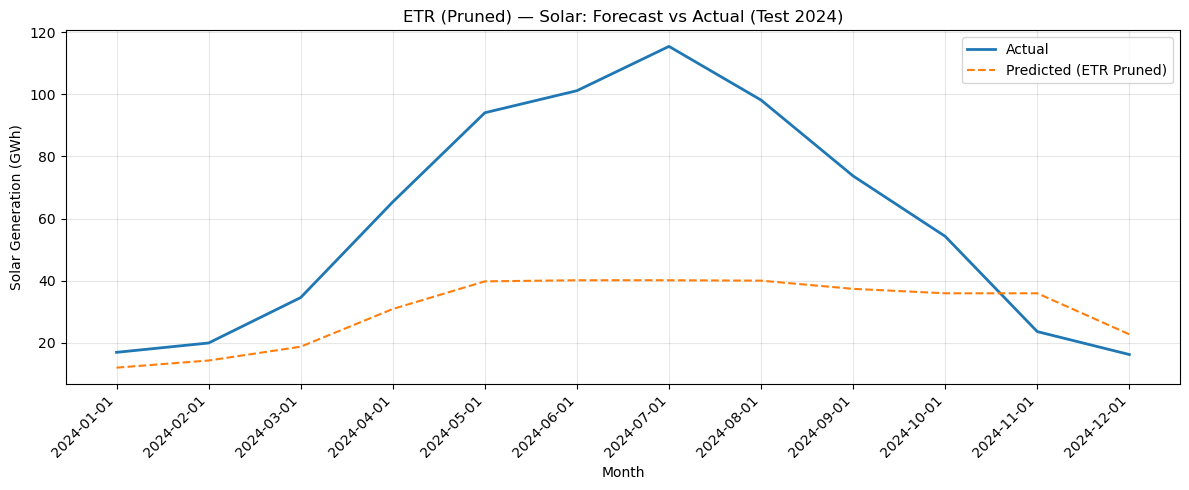

 Plot saved: C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\etr_solar\ETR_Solar_Pruned_forecast_vs_actual_2024.png


In [7]:
# plot and prediction
import pandas as pd
import matplotlib.pyplot as plt

pred_df = pd.DataFrame({
    "Date": df_oper.loc[test_mask, "Date"].dt.strftime("%Y-%m-%d").values,
    "Actual_Solar_GWh": y_test.values,
    "ETR_Pruned_Pred_Solar_GWh": y_pred_aligned
})
pred_csv = os.path.join(TABLE_DIR, "ETR_Solar_Pruned_predictions_2024.csv")
pred_df.to_csv(pred_csv, index=False)
print(f" Predictions CSV: {pred_csv}")

plt.figure(figsize=(12, 5))
plt.plot(pred_df["Date"], pred_df["Actual_Solar_GWh"], label="Actual", linewidth=2)
plt.plot(pred_df["Date"], pred_df["ETR_Pruned_Pred_Solar_GWh"], label="Predicted (ETR Pruned)", linestyle="--")
plt.title("ETR (Pruned) — Solar: Forecast vs Actual (Test 2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.xticks(rotation=45, ha="right"); plt.grid(True, alpha=0.3); plt.legend()
plot_path = os.path.join(FIG_DIR, "ETR_Solar_Pruned_forecast_vs_actual_2024.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=300); 
plt.show()
plt.close()
print(f" Plot saved: {plot_path}")


In [ ]:
# SHAP for pruned model 
import numpy as np, shap, matplotlib.pyplot as plt

# TreeExplainer on test features used for training
explainer = shap.TreeExplainer(best_model)
shap_vals = explainer.shap_values(X_test_used)

# Top-10 table
mean_abs = np.abs(shap_vals).mean(axis=0)
top10 = pd.Series(mean_abs, index=cols_expected).sort_values(ascending=False).head(10)
top10_path = os.path.join(TABLE_DIR, "ETR_Solar_Pruned_SHAP_top10_test.csv")
top10.reset_index().rename(columns={"index":"feature",0:"mean_abs_shap"}).to_csv(top10_path, index=False)
print(f" SHAP top-10 CSV: {top10_path}")

# Summary bar
shap.summary_plot(shap_vals, X_test_used, plot_type="bar", show=False)
bar_path = os.path.join(FIG_DIR, "ETR_Solar_Pruned_SHAP_summary_bar.png")
plt.tight_layout(); plt.savefig(bar_path, dpi=300, bbox_inches="tight");
plt.show() 
plt.close()
print(f" SHAP bar: {bar_path}")

# Beeswarm
shap.summary_plot(shap_vals, X_test_used, show=False)
bees_path = os.path.join(FIG_DIR, "ETR_Solar_Pruned_SHAP_beeswarm.png")
plt.tight_layout(); plt.savefig(bees_path, dpi=300, bbox_inches="tight"); 
plt.show()
plt.close()
print(f" SHAP beeswarm: {bees_path}")

# Waterfall pick largest absolute residual month
resid = np.abs(y_test.values - y_pred_aligned)
i = int(np.argmax(resid))

# Increase figure size before plotting for readablitiy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6)) 

try:
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value, shap_vals[i],
        feature_names=cols_expected, max_display=10, show=False
    )
except Exception:
    exp = shap.Explanation(
        values=shap_vals[i],
        base_values=explainer.expected_value,
        data=X_test_used.iloc[i].values,
        feature_names=cols_expected
    )
    shap.plots.waterfall(exp, max_display=10, show=False)

water_path = os.path.join(FIG_DIR, "ETR_Solar_Pruned_SHAP_waterfall_sample.png")
plt.tight_layout()
plt.savefig(water_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f" SHAP waterfall: {water_path}")

